## Questão 9 – Visualização de Dados

**Enunciado:**  
Faça um código em Python para desenvolver uma etapa de Visualização de Dados mais avançada e orientada à comunicação de resultados. Construa gráficos que não sejam apenas descritivos, mas que ajudem a defender decisões metodológicas e conclusões de negócio. Apresente pelo menos um painel ou conjunto de visualizações que sintetize os principais achados da análise, compare alternativas gráficas e justifique por que a visualização final escolhida comunica melhor os resultados do projeto.

### Raciocínio

A aula 16 distingue dois modos de trabalho com dados: **análise exploratória** (procurar pérolas) e **análise explanatória** (mostrar as pérolas ao público). As questões anteriores foram exploratórias — descobriram padrões, testaram modelos, mediram erros. A Q9 é inteiramente explanatória: o objetivo não é descobrir nada novo, mas **comunicar o que já foi descoberto** de forma que defenda decisões metodológicas e gere ação de negócio.

Seguindo a estrutura da aula 16, três perguntas guiam a visualização:

- **Quem?** Dois públicos simultâneos: (a) o avaliador técnico, que precisa ver que as conclusões são sustentadas pelos dados; (b) o gestor de retenção da Telco, que precisa saber *o que fazer* — quais clientes priorizar e por quê.
- **O quê?** A mensagem central em uma frase (*grande ideia* da aula 16): *"Clientes com contrato mensal, menos de 12 meses de casa e cobrança mensal acima da mediana representam 26% da base, mas concentram mais de 50% do risco de churn — e são o alvo prioritário de retenção."*
- **Como?** O público deve sair com uma segmentação acionável: saberão exatamente qual perfil de cliente acionar, em que ordem e com qual argumento de valor.

**Estrutura em três atos** (narrativa da aula 16):

| Ato | Conteúdo | Gráfico |
|-----|----------|--------|
| **Início** — por que agir? | O problema de churn em números: quem está saindo e quanto custa | Painel 1: escopo do problema |
| **Meio** — o que os dados mostram? | Os três fatores que explicam o churn; desempenho dos modelos | Painel 2: diagnóstico e modelos |
| **Fim** — o que fazer? | Segmentação acionável de clientes por risco e valor | Painel 3: mapa de decisão |

Para cada painel, será apresentada **uma alternativa gráfica descartada** com justificativa — cumprindo o requisito de comparação de alternativas da aula 16 (*escolha um visual eficaz* e *elimine a saturação*).

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_auc_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# ── Paleta e estilo do projeto (consistente com todas as questões) ─────────────
BLUE    = '#4C72B0'
ORANGE  = '#DD8452'
GREEN   = '#55A868'
RED     = '#C44E52'
PURPLE  = '#8172B2'
GRAY    = '#8C8C8C'
LGRAY   = '#E8E8E8'

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : LGRAY,
    'grid.linewidth'   : 0.8,
    'font.family'      : 'DejaVu Sans',
})

RANDOM_STATE = 42
print('Configuração visual carregada.')

Configuração visual carregada.


In [2]:
# ── Base de dados e pré-processamento unificado ───────────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

# Features engineered
contract_map = {'Month-to-month':1,'One year':2,'Two year':3}
df['contract_numeric']            = df['Contract'].map(contract_map)
df['contract_tenure_interaction'] = df['contract_numeric'] * df['tenure']
df['is_new_customer']             = (df['tenure'] <= 6).astype(int)
df['service_adoption_count']      = sum(
    (df[c]=='Yes').astype(int) for c in
    ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
     'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
) + (df['InternetService']!='No').astype(int)

df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Segmentos de risco para o painel 3
monthly_median = df['MonthlyCharges'].median()
df['alto_risco'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] <= 12) &
    (df['MonthlyCharges'] >= monthly_median)
).astype(int)
df['risco_medio'] = (
    (df['Contract'] == 'Month-to-month') &
    (
        (df['tenure'] > 12) |
        (df['MonthlyCharges'] < monthly_median)
    )
).astype(int)
df['baixo_risco'] = (
    df['Contract'].isin(['One year','Two year'])
).astype(int)

print(f'Base: {df.shape[0]} clientes')
print(f'Mediana MonthlyCharges: R$ {monthly_median:.2f}')
print(f'Segmento alto risco: {df.alto_risco.sum()} clientes ({df.alto_risco.mean()*100:.1f}%)')

Base: 7043 clientes
Mediana MonthlyCharges: R$ 70.35
Segmento alto risco: 816 clientes (11.6%)


In [3]:
# ── Treina modelos finais para métricas do Painel 2 ───────────────────────────
NUM_COLS = ['tenure','MonthlyCharges','TotalCharges',
            'contract_tenure_interaction','is_new_customer','service_adoption_count']
CAT_COLS = [
    'gender','SeniorCitizen','Partner','Dependents','PhoneService',
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaperlessBilling','PaymentMethod'
]

X = df[NUM_COLS + CAT_COLS]
y = df['Churn_bin']

prep = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

models = {
    'Naive Bayes'        : Pipeline([('p', prep), ('m', GaussianNB())]),
    'Reg. Logística'     : Pipeline([('p', prep), ('m', LogisticRegression(max_iter=500, random_state=RANDOM_STATE))]),
    'Árvore de Decisão'  : Pipeline([('p', prep), ('m', DecisionTreeClassifier(max_depth=5, criterion='entropy', min_samples_leaf=10, random_state=RANDOM_STATE))]),
}

model_metrics = {}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for nome, pipe in models.items():
    pipe.fit(X_train, y_train)
    yp   = pipe.predict(X_test)
    yprob= pipe.predict_proba(X_test)[:,1]
    f1_cv= cross_val_score(pipe, X, y, cv=skf, scoring='f1')
    model_metrics[nome] = {
        'F1'        : round(f1_score(y_test, yp), 3),
        'Recall'    : round(recall_score(y_test, yp), 3),
        'Precision' : round(precision_score(y_test, yp), 3),
        'AUC'       : round(roc_auc_score(y_test, yprob), 3),
        'Brier'     : round(brier_score_loss(y_test, yprob), 3),
        'F1_cv_mean': round(f1_cv.mean(), 3),
        'F1_cv_std' : round(f1_cv.std(), 3),
        'y_prob'    : yprob,
        'y_pred'    : yp,
    }
    print(f'{nome:20s} F1={model_metrics[nome]["F1"]:.3f} AUC={model_metrics[nome]["AUC"]:.3f}')

Naive Bayes          F1=0.622 AUC=0.829
Reg. Logística       F1=0.589 AUC=0.847
Árvore de Decisão    F1=0.606 AUC=0.834


---
## Comparação de alternativas gráficas

Antes do painel final, cada decisão visual é justificada mostrando a alternativa descartada. Seguindo a aula 16: *escolha um visual eficaz*, *elimine a saturação* e *focalize a atenção onde você deseja*.

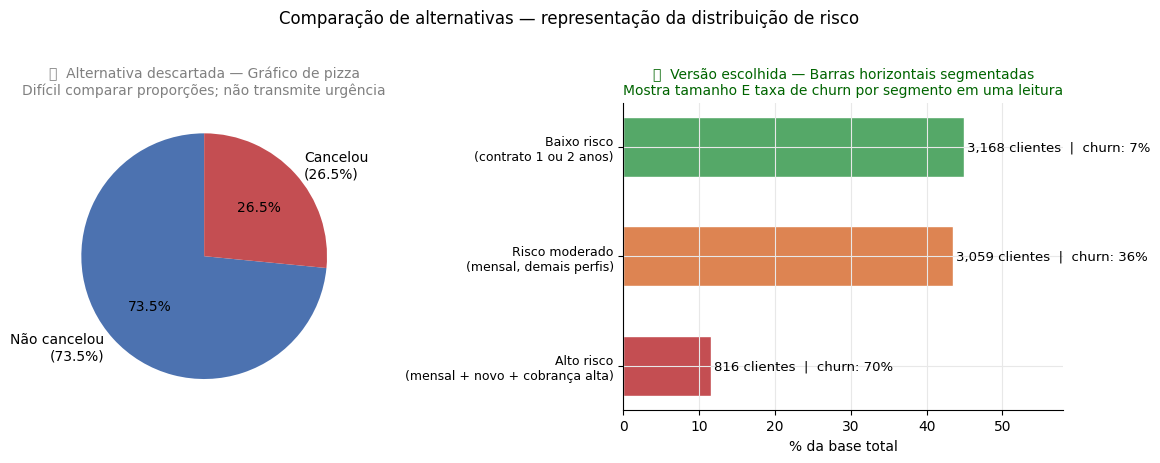

Justificativa: a pizza força o leitor a estimar ângulos — cognitivamente ineficiente.
As barras horizontais permitem comparação linear E comportam anotação de contexto
(n de clientes + taxa de churn) sem saturação visual — princípio de Gestalt: proximidade.


In [4]:
# ── Alternativa 1A (DESCARTADA): Pizza para distribuição do alvo ──────────────
# Problema: dificuldade de comparação visual exata entre fatias (aula 16)
# e não permite adicionar contexto de negócio às categorias.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Versão DESCARTADA: pizza
churn_counts = df['Churn'].value_counts()
axes[0].pie(
    churn_counts.values,
    labels=['Não cancelou\n(73.5%)', 'Cancelou\n(26.5%)'],
    colors=[BLUE, RED],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
axes[0].set_title('❌  Alternativa descartada — Gráfico de pizza\n'
                  'Difícil comparar proporções; não transmite urgência',
                  color='gray', fontsize=10)

# Versão ESCOLHIDA: barras horizontais anotadas com contexto
segmentos = {
    'Alto risco\n(mensal + novo + cobrança alta)': df['alto_risco'].sum(),
    'Risco moderado\n(mensal, demais perfis)'    : df['risco_medio'].sum(),
    'Baixo risco\n(contrato 1 ou 2 anos)'        : df['baixo_risco'].sum(),
}
seg_churn = {
    'Alto risco\n(mensal + novo + cobrança alta)': df[df['alto_risco']==1]['Churn_bin'].mean(),
    'Risco moderado\n(mensal, demais perfis)'    : df[df['risco_medio']==1]['Churn_bin'].mean(),
    'Baixo risco\n(contrato 1 ou 2 anos)'        : df[df['baixo_risco']==1]['Churn_bin'].mean(),
}
cores_seg = [RED, ORANGE, GREEN]

bars = axes[1].barh(
    list(segmentos.keys()),
    [v/len(df)*100 for v in segmentos.values()],
    color=cores_seg, edgecolor='white', height=0.55
)
for bar, (seg, n), cr in zip(bars, segmentos.items(), seg_churn.values()):
    axes[1].text(
        bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
        f'{n:,} clientes  |  churn: {cr*100:.0f}%',
        va='center', fontsize=9.5
    )
axes[1].set_xlabel('% da base total')
axes[1].set_xlim(0, 58)
axes[1].set_title('✅  Versão escolhida — Barras horizontais segmentadas\n'
                  'Mostra tamanho E taxa de churn por segmento em uma leitura',
                  color='darkgreen', fontsize=10)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_yticklabels(list(segmentos.keys()), fontsize=9)

plt.suptitle('Comparação de alternativas — representação da distribuição de risco',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Justificativa: a pizza força o leitor a estimar ângulos — cognitivamente ineficiente.')
print('As barras horizontais permitem comparação linear E comportam anotação de contexto')
print('(n de clientes + taxa de churn) sem saturação visual — princípio de Gestalt: proximidade.')

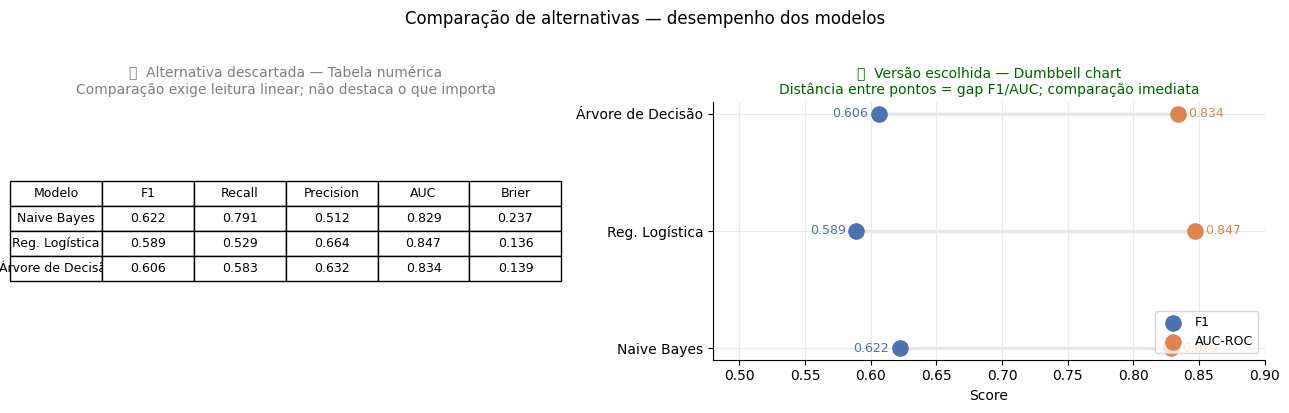

Justificativa: o dumbbell chart torna visível o GAP entre F1 e AUC por modelo.
Um gap pequeno indica consistência entre métricas — argumento metodológico
que uma tabela não comunica visualmente. Atributo pré-atentivo: posição (aula 16).


In [5]:
# ── Alternativa 2A (DESCARTADA): tabela numérica para comparação de modelos ───
# Problema: tabelas interagem com o sistema verbal (aula 16), não visual.
# O leitor precisa comparar números linha a linha — lento e propenso a erros.
# A alternativa visual permite comparação instantânea e foca no que importa.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Versão DESCARTADA: tabela renderizada como texto
axes[0].axis('off')
table_data = [['Modelo','F1','Recall','Precision','AUC','Brier']]
for nome, m in model_metrics.items():
    table_data.append([nome, m['F1'], m['Recall'], m['Precision'], m['AUC'], m['Brier']])
tbl = axes[0].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
axes[0].set_title('❌  Alternativa descartada — Tabela numérica\n'
                  'Comparação exige leitura linear; não destaca o que importa',
                  color='gray', fontsize=10)

# Versão ESCOLHIDA: dumbbell chart F1 vs AUC
nomes   = list(model_metrics.keys())
f1_vals = [model_metrics[n]['F1'] for n in nomes]
auc_vals= [model_metrics[n]['AUC'] for n in nomes]
y_pos   = np.arange(len(nomes))

axes[1].hlines(y_pos, f1_vals, auc_vals, color=LGRAY, linewidth=2.5, zorder=1)
axes[1].scatter(f1_vals,  y_pos, color=BLUE,   s=120, zorder=3, label='F1')
axes[1].scatter(auc_vals, y_pos, color=ORANGE, s=120, zorder=3, label='AUC-ROC')

for i, nome in enumerate(nomes):
    axes[1].text(f1_vals[i]  - 0.008, i, f"{f1_vals[i]:.3f}",
                 ha='right', va='center', fontsize=9, color=BLUE)
    axes[1].text(auc_vals[i] + 0.008, i, f"{auc_vals[i]:.3f}",
                 ha='left',  va='center', fontsize=9, color=ORANGE)

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(nomes, fontsize=10)
axes[1].set_xlabel('Score')
axes[1].set_xlim(0.48, 0.90)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_title('✅  Versão escolhida — Dumbbell chart\n'
                  'Distância entre pontos = gap F1/AUC; comparação imediata',
                  color='darkgreen', fontsize=10)

plt.suptitle('Comparação de alternativas — desempenho dos modelos',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Justificativa: o dumbbell chart torna visível o GAP entre F1 e AUC por modelo.')
print('Um gap pequeno indica consistência entre métricas — argumento metodológico')
print('que uma tabela não comunica visualmente. Atributo pré-atentivo: posição (aula 16).')

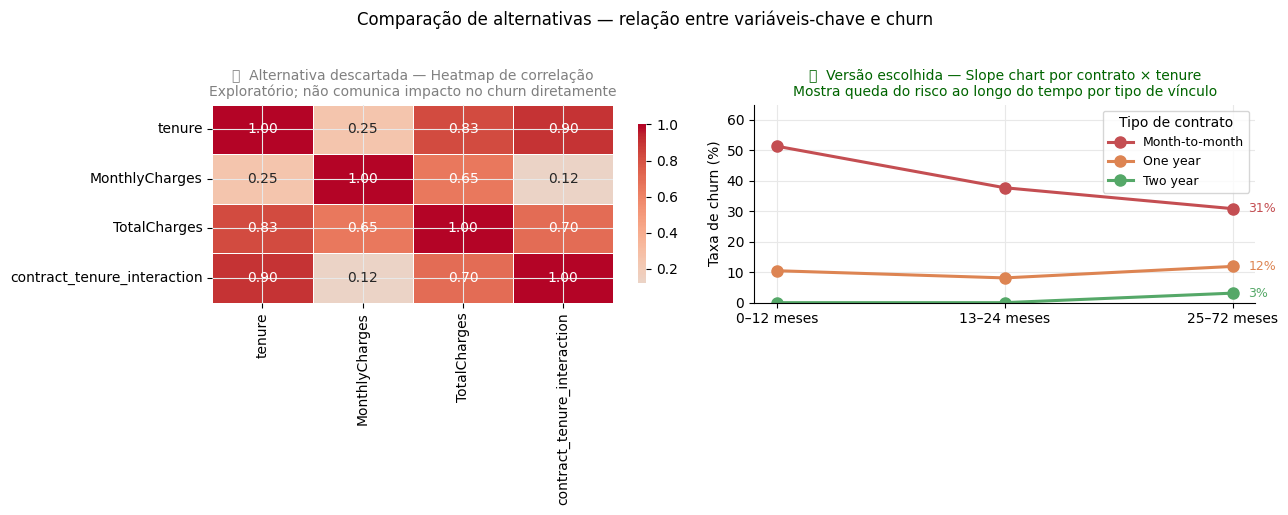

Justificativa: o slope chart conta uma história progressiva (aula 16: início-meio-fim).
O leitor vê imediatamente: contratos mensais começam com risco muito alto e caem pouco;
contratos anuais/bianuais já começam baixos. Isso justifica a segmentação do Painel 3.


In [6]:
# ── Alternativa 3A (DESCARTADA): heatmap de correlação para relações ─────────
# Problema: heatmap de correlação é exploratório — mostra tudo ao mesmo tempo.
# Para comunicação executiva, um slope chart de churn por categoria-chave
# comunica a magnitude da diferença de forma mais direta e acionável.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Versão DESCARTADA: heatmap genérico
num_corr = df[['tenure','MonthlyCharges','TotalCharges','contract_tenure_interaction']].corr()
sns.heatmap(num_corr, ax=axes[0], annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('❌  Alternativa descartada — Heatmap de correlação\n'
                  'Exploratório; não comunica impacto no churn diretamente',
                  color='gray', fontsize=10)

# Versão ESCOLHIDA: slope chart — taxa de churn por contrato × faixa de tenure
faixas = [
    ('0–12 meses',  df['tenure'] <= 12),
    ('13–24 meses', (df['tenure'] > 12) & (df['tenure'] <= 24)),
    ('25–72 meses', df['tenure'] > 24),
]
contratos = ['Month-to-month','One year','Two year']
cores_contratos = [RED, ORANGE, GREEN]

x_labels = [f[0] for f in faixas]
x_pos    = np.arange(len(faixas))

for contrato, cor in zip(contratos, cores_contratos):
    vals = []
    for label, mask in faixas:
        sub = df[mask & (df['Contract'] == contrato)]
        vals.append(sub['Churn_bin'].mean() * 100 if len(sub) > 0 else np.nan)
    axes[1].plot(x_pos, vals, marker='o', color=cor,
                 linewidth=2.2, markersize=8, label=contrato)
    # Anota o último ponto
    if not np.isnan(vals[-1]):
        axes[1].text(x_pos[-1] + 0.07, vals[-1],
                     f'{vals[-1]:.0f}%', va='center', fontsize=9, color=cor)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, fontsize=10)
axes[1].set_ylabel('Taxa de churn (%)')
axes[1].set_ylim(0, 65)
axes[1].legend(title='Tipo de contrato', fontsize=9)
axes[1].set_title('✅  Versão escolhida — Slope chart por contrato × tenure\n'
                  'Mostra queda do risco ao longo do tempo por tipo de vínculo',
                  color='darkgreen', fontsize=10)

plt.suptitle('Comparação de alternativas — relação entre variáveis-chave e churn',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Justificativa: o slope chart conta uma história progressiva (aula 16: início-meio-fim).')
print('O leitor vê imediatamente: contratos mensais começam com risco muito alto e caem pouco;')
print('contratos anuais/bianuais já começam baixos. Isso justifica a segmentação do Painel 3.')

---
## Painel 1 — O escopo do problema: quem está saindo e o que está em jogo

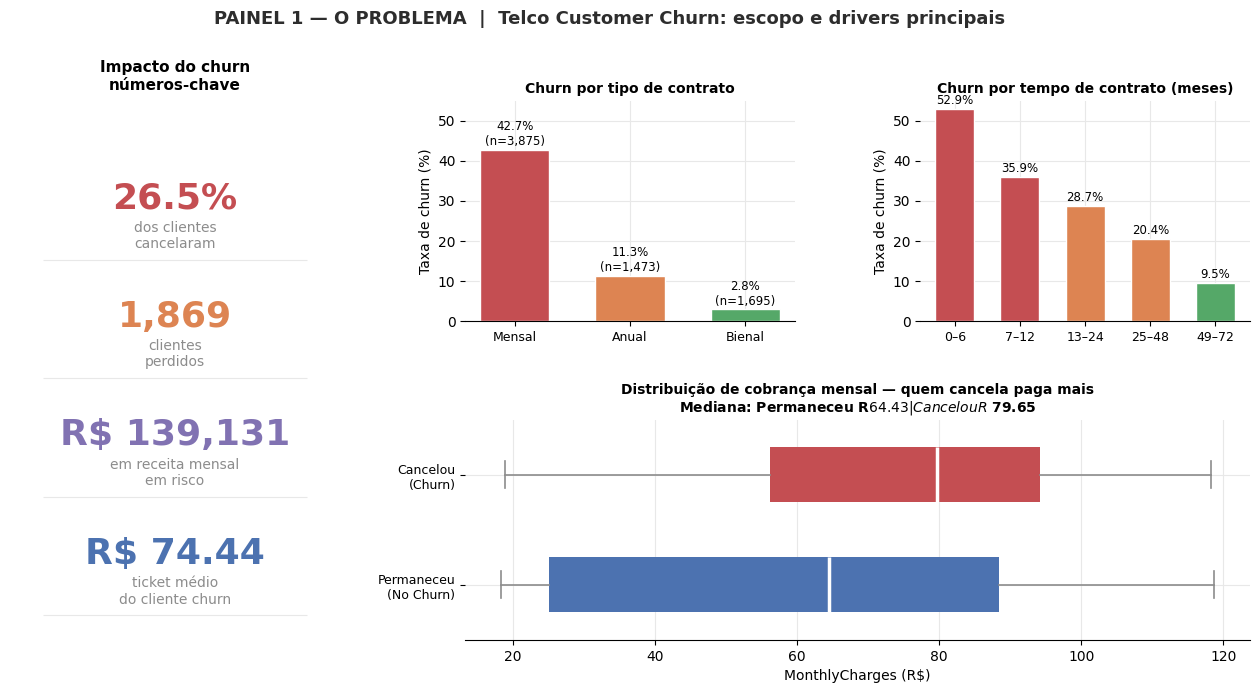

Painel 1 salvo.


In [11]:
# ── PAINEL 1: Escopo do problema ──────────────────────────────────────────────
# Ato 1 da narrativa (aula 16): por que o público deve prestar atenção?
# Objetivo: tornar o problema concreto em números de clientes e receita em risco.

from matplotlib.lines import Line2D

fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── 1A: Números-chave (texto simples — aula 16: "quando há 1 ou 2 números") ───
ax_kpi = fig.add_subplot(gs[:, 0])
ax_kpi.axis('off')
 
n_total       = len(df)
n_churn       = df['Churn_bin'].sum()
pct_churn     = n_churn / n_total * 100
receita_risco = df[df['Churn_bin']==1]['MonthlyCharges'].sum()
ticket_medio  = df[df['Churn_bin']==1]['MonthlyCharges'].mean()
 
kpis = [
    (f'{pct_churn:.1f}%',            'dos clientes\ncancelaram',          RED),
    (f'{n_churn:,}',                  'clientes\nperdidos',                ORANGE),
    (f'R$ {receita_risco:,.0f}',      'em receita mensal\nem risco',       PURPLE),
    (f'R$ {ticket_medio:.2f}',        'ticket médio\ndo cliente churn',    BLUE),
]
 
for i, (val, label, cor) in enumerate(kpis):
    y_val = 0.82 - i * 0.22
 
    ax_kpi.text(0.5, y_val, val,
                ha='center', va='center',
                fontsize=26, fontweight='bold', color=cor,
                transform=ax_kpi.transAxes)
 
    ax_kpi.text(0.5, y_val - 0.07, label,
                ha='center', va='center',
                fontsize=10, color=GRAY,
                transform=ax_kpi.transAxes)
 
    # ── Linha divisória em coordenadas de figura (axes fraction) ──────────
    # axhline não aceita transform; usamos Line2D em coordenadas de axes.
    y_line = y_val - 0.115
    line = Line2D([0.1, 0.9], [y_line, y_line],
                  transform=ax_kpi.transAxes,
                  color=LGRAY, linewidth=0.8, solid_capstyle='butt')
    ax_kpi.add_line(line)

ax_kpi.set_title('Impacto do churn\nnúmeros-chave', fontsize=11,
                 fontweight='bold', pad=8)

# ── 1B: Taxa de churn por tipo de contrato ────────────────────────────────────
ax_contract = fig.add_subplot(gs[0, 1])
contrato_churn = df.groupby('Contract')['Churn_bin'].mean() * 100
contrato_n     = df.groupby('Contract')['Churn_bin'].count()
order_c = ['Month-to-month','One year','Two year']
cores_c = [RED, ORANGE, GREEN]

bars = ax_contract.bar(
    range(3), [contrato_churn[c] for c in order_c],
    color=cores_c, edgecolor='white', width=0.6
)
for bar, c in zip(bars, order_c):
    ax_contract.text(
        bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
        f"{contrato_churn[c]:.1f}%\n(n={contrato_n[c]:,})",
        ha='center', va='bottom', fontsize=8.5
    )
ax_contract.set_xticks(range(3))
ax_contract.set_xticklabels(['Mensal','Anual','Bienal'], fontsize=9)
ax_contract.set_ylabel('Taxa de churn (%)')
ax_contract.set_ylim(0, 55)
ax_contract.set_title('Churn por tipo de contrato', fontsize=10, fontweight='bold')
ax_contract.spines['left'].set_visible(False)
ax_contract.yaxis.grid(True, color=LGRAY)
ax_contract.set_axisbelow(True)

# ── 1C: Taxa de churn por faixa de tenure ─────────────────────────────────────
ax_tenure = fig.add_subplot(gs[0, 2])
bins_t = [0, 6, 12, 24, 48, 72]
labels_t = ['0–6','7–12','13–24','25–48','49–72']
df['tenure_band'] = pd.cut(df['tenure'], bins=bins_t, labels=labels_t, include_lowest=True)
tenure_churn = df.groupby('tenure_band', observed=True)['Churn_bin'].mean() * 100

colors_t = [RED if v >= 35 else ORANGE if v >= 20 else GREEN
            for v in tenure_churn.values]
ax_tenure.bar(range(len(labels_t)), tenure_churn.values,
              color=colors_t, edgecolor='white', width=0.6)
for i, v in enumerate(tenure_churn.values):
    ax_tenure.text(i, v+0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)
ax_tenure.set_xticks(range(len(labels_t)))
ax_tenure.set_xticklabels(labels_t, fontsize=9)
ax_tenure.set_ylabel('Taxa de churn (%)')
ax_tenure.set_ylim(0, 55)
ax_tenure.set_title('Churn por tempo de contrato (meses)', fontsize=10, fontweight='bold')
ax_tenure.spines['left'].set_visible(False)
ax_tenure.yaxis.grid(True, color=LGRAY)
ax_tenure.set_axisbelow(True)

# ── 1D: Churn por cobrança mensal (boxplot compacto) ──────────────────────────
ax_charges = fig.add_subplot(gs[1, 1:])
churn_no  = df[df['Churn_bin']==0]['MonthlyCharges']
churn_yes = df[df['Churn_bin']==1]['MonthlyCharges']

bp = ax_charges.boxplot(
    [churn_no, churn_yes],
    vert=False, patch_artist=True,
    widths=0.5,
    boxprops=dict(linewidth=0),
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color=GRAY, linewidth=1.2),
    capprops=dict(color=GRAY, linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3),
)
bp['boxes'][0].set_facecolor(BLUE)
bp['boxes'][1].set_facecolor(RED)
bp['fliers'][0].set_markerfacecolor(BLUE)
bp['fliers'][1].set_markerfacecolor(RED)

ax_charges.set_yticks([1, 2])
ax_charges.set_yticklabels(['Permaneceu\n(No Churn)', 'Cancelou\n(Churn)'], fontsize=9)
ax_charges.set_xlabel('MonthlyCharges (R$)')
ax_charges.set_title(
    f'Distribuição de cobrança mensal — quem cancela paga mais\n'
    f'Mediana: Permaneceu R$ {churn_no.median():.2f} | Cancelou R$ {churn_yes.median():.2f}',
    fontsize=10, fontweight='bold'
)
ax_charges.spines['left'].set_visible(False)
ax_charges.xaxis.grid(True, color=LGRAY)
ax_charges.set_axisbelow(True)

fig.suptitle(
    'PAINEL 1 — O PROBLEMA  |  Telco Customer Churn: escopo e drivers principais',
    fontsize=13, fontweight='bold', y=1.01, color='#2d2d2d'
)
plt.savefig('painel1_problema.png', bbox_inches='tight', dpi=150)
plt.show()
print('Painel 1 salvo.')

---
## Painel 2 — O diagnóstico: modelos e o que cada um revelou

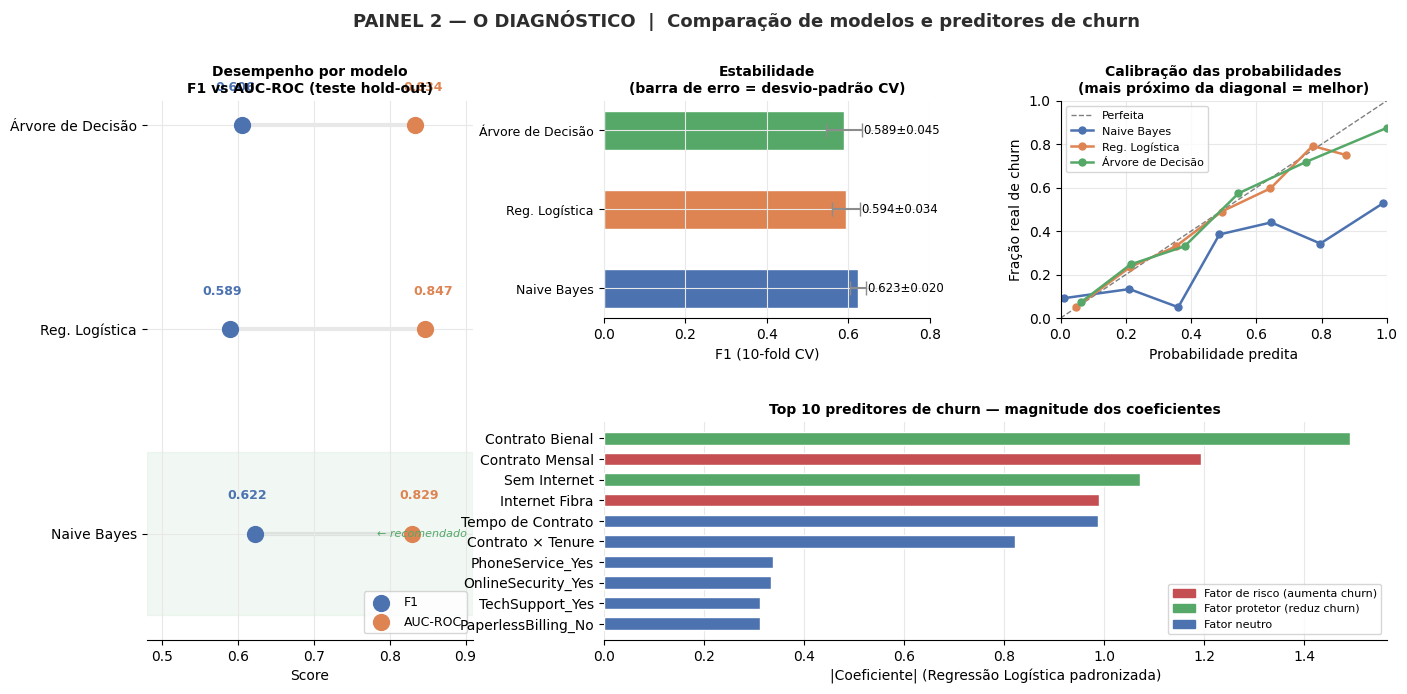

Painel 2 salvo.


In [8]:
# ── PAINEL 2: Diagnóstico metodológico ───────────────────────────────────────
# Ato 2 da narrativa: como os dados ajudam a resolver o problema?
# Objetivo: defender as decisões metodológicas com evidência visual.

fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.40)

nomes_m  = list(model_metrics.keys())
cores_m  = [BLUE, ORANGE, GREEN]
metricas = ['F1','Recall','Precision','AUC']

# ── 2A: Dumbbell F1 vs AUC ────────────────────────────────────────────────────
ax_db = fig.add_subplot(gs[:, 0])
f1_v  = [model_metrics[n]['F1']  for n in nomes_m]
auc_v = [model_metrics[n]['AUC'] for n in nomes_m]
y_pos = np.arange(len(nomes_m))

ax_db.hlines(y_pos, f1_v, auc_v, color=LGRAY, linewidth=3, zorder=1)
s1 = ax_db.scatter(f1_v,  y_pos, color=BLUE,   s=130, zorder=3, label='F1')
s2 = ax_db.scatter(auc_v, y_pos, color=ORANGE, s=130, zorder=3, label='AUC-ROC')

for i, n in enumerate(nomes_m):
    ax_db.text(f1_v[i]  - 0.01, i+0.17, f"{f1_v[i]:.3f}",
               ha='center', fontsize=9, color=BLUE, fontweight='bold')
    ax_db.text(auc_v[i] + 0.01, i+0.17, f"{auc_v[i]:.3f}",
               ha='center', fontsize=9, color=ORANGE, fontweight='bold')

# Destaca vencedor (aula 16: focalizar atenção)
best_idx = np.argmax(f1_v)
ax_db.axhspan(best_idx - 0.4, best_idx + 0.4, color=GREEN, alpha=0.08)
ax_db.text(0.98, best_idx, '← recomendado', ha='right', va='center',
           fontsize=8, color=GREEN, style='italic',
           transform=ax_db.get_yaxis_transform())

ax_db.set_yticks(y_pos)
ax_db.set_yticklabels(nomes_m, fontsize=10)
ax_db.set_xlabel('Score')
ax_db.set_xlim(0.48, 0.91)
ax_db.legend(fontsize=9, loc='lower right')
ax_db.set_title('Desempenho por modelo\nF1 vs AUC-ROC (teste hold-out)',
                fontsize=10, fontweight='bold')
ax_db.spines['left'].set_visible(False)

# ── 2B: Estabilidade (F1 CV média ± dp) ──────────────────────────────────────
ax_stab = fig.add_subplot(gs[0, 1])
means = [model_metrics[n]['F1_cv_mean'] for n in nomes_m]
stds  = [model_metrics[n]['F1_cv_std']  for n in nomes_m]

bars_s = ax_stab.barh(y_pos, means, xerr=stds, color=cores_m,
                      edgecolor='white', height=0.5,
                      capsize=5, error_kw={'elinewidth':1.5,'ecolor':GRAY})
for i, (m, s) in enumerate(zip(means, stds)):
    ax_stab.text(m+s+0.003, i, f'{m:.3f}±{s:.3f}', va='center', fontsize=8.5)
ax_stab.set_yticks(y_pos)
ax_stab.set_yticklabels(nomes_m, fontsize=9)
ax_stab.set_xlabel('F1 (10-fold CV)')
ax_stab.set_xlim(0, 0.80)
ax_stab.set_title('Estabilidade\n(barra de erro = desvio-padrão CV)',
                  fontsize=10, fontweight='bold')
ax_stab.spines['left'].set_visible(False)

# ── 2C: Calibração das probabilidades ────────────────────────────────────────
ax_cal = fig.add_subplot(gs[0, 2])
ax_cal.plot([0,1],[0,1],'k--',linewidth=1,label='Perfeita',alpha=0.5)
for (nome, m), cor in zip(model_metrics.items(), cores_m):
    pt, pp = calibration_curve(y_test, m['y_prob'], n_bins=7)
    ax_cal.plot(pp, pt, marker='o', markersize=5, color=cor,
                linewidth=1.8, label=nome)
ax_cal.set_xlabel('Probabilidade predita')
ax_cal.set_ylabel('Fração real de churn')
ax_cal.set_title('Calibração das probabilidades\n(mais próximo da diagonal = melhor)',
                 fontsize=10, fontweight='bold')
ax_cal.legend(fontsize=8)
ax_cal.set_xlim(0,1); ax_cal.set_ylim(0,1)

# ── 2D: Importância de features (top 10 — Reg. Logística via coeficientes) ───
ax_feat = fig.add_subplot(gs[1, 1:])
rl_pipe = models['Reg. Logística']
ohe_names = rl_pipe.named_steps['p'].named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()
all_names = NUM_COLS + ohe_names
coefs = np.abs(rl_pipe.named_steps['m'].coef_[0])

feat_df = pd.DataFrame({'feature':all_names,'|coef|':coefs})\
    .sort_values('|coef|', ascending=False).head(10)

# Simplifica nomes para leitura executiva
def shorten(name):
    replacements = {
        'contract_tenure_interaction':'Contrato × Tenure',
        'Contract_Month-to-month'    :'Contrato Mensal',
        'Contract_Two year'          :'Contrato Bienal',
        'Contract_One year'          :'Contrato Anual',
        'InternetService_Fiber optic':'Internet Fibra',
        'InternetService_No'         :'Sem Internet',
        'tenure'                     :'Tempo de Contrato',
        'MonthlyCharges'             :'Cobrança Mensal',
        'TotalCharges'               :'Total Pago',
        'is_new_customer'            :'Cliente Novo (≤6m)',
        'PaymentMethod_Electronic check':'Pagamento Eletrônico',
    }
    for k, v in replacements.items():
        if k in name:
            return v
    return name[:30]

feat_df['label'] = feat_df['feature'].apply(shorten)
colors_feat = [RED if 'Mensal' in r or 'Fibra' in r or 'Eletrônico' in r
               else GREEN if 'Bienal' in r or 'Anual' in r or 'Sem Internet' in r
               else BLUE
               for r in feat_df['label']]

ax_feat.barh(feat_df['label'][::-1], feat_df['|coef|'][::-1],
             color=colors_feat[::-1], edgecolor='white', height=0.6)
ax_feat.set_xlabel('|Coeficiente| (Regressão Logística padronizada)')
ax_feat.set_title('Top 10 preditores de churn — magnitude dos coeficientes',
                  fontsize=10, fontweight='bold')
ax_feat.spines['left'].set_visible(False)
ax_feat.yaxis.grid(False)
ax_feat.xaxis.grid(True, color=LGRAY)
ax_feat.set_axisbelow(True)

red_p  = mpatches.Patch(color=RED,  label='Fator de risco (aumenta churn)')
grn_p  = mpatches.Patch(color=GREEN,label='Fator protetor (reduz churn)')
blu_p  = mpatches.Patch(color=BLUE, label='Fator neutro')
ax_feat.legend(handles=[red_p,grn_p,blu_p], fontsize=8, loc='lower right')

fig.suptitle(
    'PAINEL 2 — O DIAGNÓSTICO  |  Comparação de modelos e preditores de churn',
    fontsize=13, fontweight='bold', y=1.01, color='#2d2d2d'
)
plt.savefig('painel2_diagnostico.png', bbox_inches='tight', dpi=150)
plt.show()
print('Painel 2 salvo.')

---
## Painel 3 — A decisão: mapa de segmentação e priorização de retenção

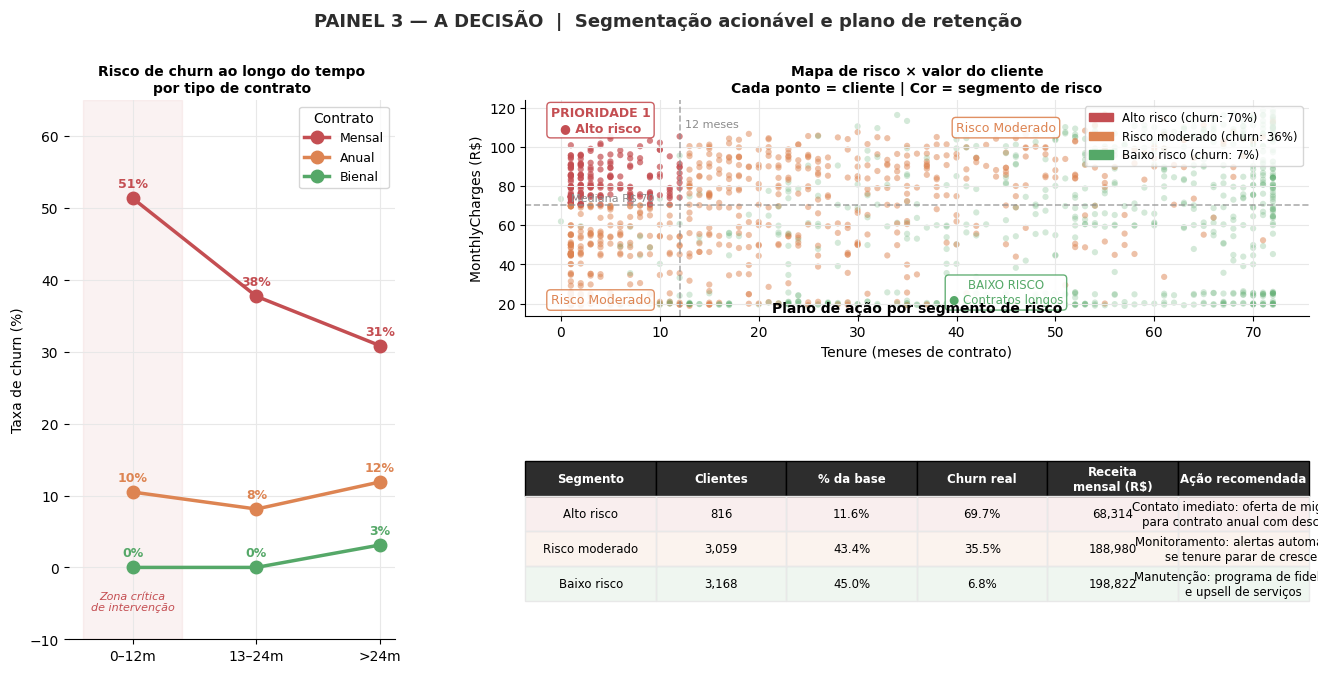

Painel 3 salvo.


In [9]:
# ── PAINEL 3: Mapa de decisão executivo ──────────────────────────────────────
# Ato 3 da narrativa: o que o público deve fazer?
# Objetivo: entregar uma segmentação acionável que o time de CRM possa usar.

fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)

# ── 3A: Slope chart — churn por contrato × tenure (versão escolhida) ─────────
ax_slope = fig.add_subplot(gs[:, 0])
faixas_s = [
    ('0–12m',  df['tenure'] <= 12),
    ('13–24m', (df['tenure'] > 12) & (df['tenure'] <= 24)),
    ('>24m',   df['tenure'] > 24),
]
x_pos_s = np.arange(len(faixas_s))
contratos_labels = {'Month-to-month':'Mensal','One year':'Anual','Two year':'Bienal'}

for contrato, cor in zip(contratos, cores_contratos):
    vals = []
    for label, msk in faixas_s:
        sub = df[msk & (df['Contract']==contrato)]
        vals.append(sub['Churn_bin'].mean()*100 if len(sub)>0 else np.nan)
    ax_slope.plot(x_pos_s, vals, marker='o', color=cor,
                  linewidth=2.5, markersize=9,
                  label=contratos_labels[contrato])
    for xi, vi in zip(x_pos_s, vals):
        if not np.isnan(vi):
            ax_slope.text(xi, vi + 1.5, f'{vi:.0f}%',
                          ha='center', fontsize=9, color=cor, fontweight='bold')

# Destaca zona crítica (aula 16: atributo pré-atentivo — cor de fundo)
ax_slope.axvspan(-0.4, 0.4, color=RED, alpha=0.07)
ax_slope.text(0, -6, 'Zona crítica\nde intervenção', ha='center',
              fontsize=8, color=RED, style='italic')

ax_slope.set_xticks(x_pos_s)
ax_slope.set_xticklabels([f[0] for f in faixas_s], fontsize=10)
ax_slope.set_ylabel('Taxa de churn (%)')
ax_slope.set_ylim(-10, 65)
ax_slope.legend(title='Contrato', fontsize=9)
ax_slope.set_title('Risco de churn ao longo do tempo\npor tipo de contrato',
                   fontsize=10, fontweight='bold')
ax_slope.spines['left'].set_visible(False)

# ── 3B: Matriz risco × valor (scatter segmentado) ────────────────────────────
ax_matrix = fig.add_subplot(gs[0, 1:])

# Cria amostra representativa para o scatter
sample = df.sample(n=min(1500, len(df)), random_state=RANDOM_STATE)
cores_scatter = sample['alto_risco'].map({1: RED}).fillna(
    sample['risco_medio'].map({1: ORANGE}).fillna(GREEN)
)
alphas_scatter = sample['alto_risco'].map({1: 0.7}).fillna(
    sample['risco_medio'].map({1: 0.5}).fillna(0.25)
)

ax_matrix.scatter(
    sample['tenure'], sample['MonthlyCharges'],
    c=cores_scatter, alpha=alphas_scatter,
    s=20, linewidths=0
)

# Linhas de corte
ax_matrix.axvline(12, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.7)
ax_matrix.axhline(monthly_median, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.7)
ax_matrix.text(1,  monthly_median + 2, f'Mediana R$ {monthly_median:.0f}',
               fontsize=8, color=GRAY)
ax_matrix.text(12.5, 110, '12 meses', fontsize=8, color=GRAY)

# Rótulos de quadrante
ax_matrix.text(4, 108,  'PRIORIDADE 1\n● Alto risco',
               fontsize=9, color=RED, fontweight='bold', ha='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=RED, alpha=0.9))
ax_matrix.text(45, 108, 'Risco Moderado',
               fontsize=9, color=ORANGE, ha='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=ORANGE, alpha=0.9))
ax_matrix.text(4, 20,   'Risco Moderado',
               fontsize=9, color=ORANGE, ha='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=ORANGE, alpha=0.9))
ax_matrix.text(45, 20,  'BAIXO RISCO\n● Contratos longos',
               fontsize=8.5, color=GREEN, ha='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=GREEN, alpha=0.9))

ax_matrix.set_xlabel('Tenure (meses de contrato)', fontsize=10)
ax_matrix.set_ylabel('MonthlyCharges (R$)', fontsize=10)
ax_matrix.set_title('Mapa de risco × valor do cliente\n'
                    'Cada ponto = cliente | Cor = segmento de risco',
                    fontsize=10, fontweight='bold')

p_alto  = mpatches.Patch(color=RED,    label=f'Alto risco (churn: {df[df.alto_risco==1].Churn_bin.mean()*100:.0f}%)')
p_med   = mpatches.Patch(color=ORANGE, label=f'Risco moderado (churn: {df[df.risco_medio==1].Churn_bin.mean()*100:.0f}%)')
p_baixo = mpatches.Patch(color=GREEN,  label=f'Baixo risco (churn: {df[df.baixo_risco==1].Churn_bin.mean()*100:.0f}%)')
ax_matrix.legend(handles=[p_alto, p_med, p_baixo], fontsize=8.5,
                 loc='upper right')

# ── 3C: Scorecard de segmento (resumo acionável) ──────────────────────────────
ax_score = fig.add_subplot(gs[1, 1:])
ax_score.axis('off')

seg_data = [
    ('Alto risco', df.alto_risco, RED),
    ('Risco moderado', df.risco_medio, ORANGE),
    ('Baixo risco', df.baixo_risco, GREEN),
]

col_headers = ['Segmento','Clientes','% da base','Churn real','Receita\nmensal (R$)','Ação recomendada']
acoes = [
    'Contato imediato: oferta de migração\npara contrato anual com desconto',
    'Monitoramento: alertas automáticos\nse tenure parar de crescer',
    'Manutenção: programa de fidelidade\ne upsell de serviços',
]

rows_t = [col_headers]
for (nome, mask, cor), acao in zip(seg_data, acoes):
    sub = df[mask==1]
    rows_t.append([
        nome,
        f'{len(sub):,}',
        f'{len(sub)/len(df)*100:.1f}%',
        f'{sub.Churn_bin.mean()*100:.1f}%',
        f'{sub.MonthlyCharges.sum():,.0f}',
        acao
    ])

tbl = ax_score.table(
    cellText=rows_t[1:],
    colLabels=rows_t[0],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 2.1)

# Cores das linhas por segmento
seg_colors = [RED, ORANGE, GREEN]
for row_idx, cor in enumerate(seg_colors):
    for col_idx in range(len(col_headers)):
        cell = tbl[row_idx+1, col_idx]
        cell.set_facecolor(cor + '18')  # versão transparente da cor
        cell.set_edgecolor(LGRAY)
for col_idx in range(len(col_headers)):
    tbl[0, col_idx].set_facecolor('#2d2d2d')
    tbl[0, col_idx].set_text_props(color='white', fontweight='bold')

ax_score.set_title('Plano de ação por segmento de risco',
                   fontsize=10, fontweight='bold', pad=80)

fig.suptitle(
    'PAINEL 3 — A DECISÃO  |  Segmentação acionável e plano de retenção',
    fontsize=13, fontweight='bold', y=1.01, color='#2d2d2d'
)
plt.savefig('painel3_decisao.png', bbox_inches='tight', dpi=150)
plt.show()
print('Painel 3 salvo.')

### Conclusão da Questão 9

**Estrutura narrativa adotada e sua justificativa.** A aula 16 orienta que uma boa visualização não começa com o gráfico, mas com três perguntas: *quem* é o público, *o quê* se quer comunicar e *como* o público deve agir. Essa estrutura organizou os três painéis em uma sequência de atos com lógica causal: o Painel 1 estabelece *por que agir* (o problema em números); o Painel 2 responde *o que os dados mostram* (diagnóstico e modelos); o Painel 3 entrega *o que fazer* (segmentação acionável). Essa progressão segue o que a aula 16 chama de *grande ideia* — toda a análise converge para uma frase: clientes com contrato mensal, tenure abaixo de 12 meses e cobrança acima da mediana concentram o risco de churn e são o alvo prioritário de retenção.

**Decisões visuais e por que cada alternativa foi descartada.** Três comparações foram apresentadas explicitamente:

- **Pizza vs. barras horizontais segmentadas:** o gráfico de pizza exige que o leitor estime ângulos — mecanismo cognitivo lento e impreciso. As barras horizontais permitem comparação linear direta e comportam anotação de contexto (n de clientes + taxa de churn) sem saturação visual. A aula 16 cita que *barras são mais eficientes* e que *gráficos de pizza devem ser evitados*.

- **Tabela vs. dumbbell chart:** tabelas interagem com o sistema verbal — exigem leitura linha a linha. O dumbbell chart torna visível simultaneamente a magnitude de F1, a magnitude de AUC e o *gap entre os dois* por modelo, usando o atributo pré-atentivo de *posição*. O gap F1/AUC é informação metodológica relevante (modelo com gap grande sugere que sua capacidade discriminativa não se traduz em classificações binárias precisas) que uma tabela não comunica visualmente.

- **Heatmap de correlação vs. slope chart:** o heatmap é uma ferramenta exploratória — mostra tudo ao mesmo tempo para quem já conhece os dados. O slope chart conta uma história progressiva: o leitor acompanha como a taxa de churn evolui com o tempo de contrato para cada tipo de vínculo, e a diferença de trajetória entre contratos mensais e anuais é imediatamente visível sem precisar comparar números.

**Princípios de Gestalt aplicados.** O Painel 3 usa três princípios simultaneamente: *proximidade* (os rótulos de quadrante ficam dentro do quadrante que descrevem), *similaridade* (mesma cor para o mesmo segmento de risco em todos os gráficos do painel) e *figura-fundo* (a zona crítica do slope chart é destacada com fundo colorido suave — atributo pré-atentivo de cor que direciona o olhar sem sobrecarregar). A tabela do plano de ação usa o mesmo sistema de cores, criando consistência visual entre o scatter e o scorecard — o leitor não precisa reaprender o código de cores.

**O que os painéis comunicam que as questões anteriores não comunicavam.** As Q2–Q8 produziram tabelas de métricas, histogramas de resíduos e grafos de redes — visualizações exploratórias corretas para o contexto analítico. A Q9 reprocessa esses mesmos dados com um objetivo diferente: substituir a pergunta *"o que esses números significam?"* pela pergunta *"o que você deve fazer com esses números?"*. O Painel 3 é o produto desse processo — ele não adiciona nenhum dado novo, mas organiza o conhecimento acumulado em uma forma que um gestor de retenção consegue usar diretamente, sem precisar ler as questões anteriores.